In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from dateutil.parser import parser
from sklearn.preprocessing import MinMaxScaler


In [2]:
# Get all the data
df_banks = pd.read_csv("data/banklist.csv")
df_banks_old = pd.read_csv("data/bank_failues.csv")
df_recession = pd.read_csv("data/USREC.csv")
df_banks


,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Citizens Bank,Sac City,IA,8758,Iowa Trust & Savings Bank,3-Nov-23,10545
1,Heartland Tri-State Bank,Elkhart,KS,25851,"Dream First Bank, N.A.",28-Jul-23,10544
2,First Republic Bank,San Francisco,CA,59017,"JPMorgan Chase Bank, N.A.",1-May-23,10543
3,Signature Bank,New York,NY,57053,"Flagstar Bank, N.A.",12-Mar-23,10540
4,Silicon Valley Bank,Santa Clara,CA,24735,First Citizens Bank & Trust Company,10-Mar-23,10539
...,...,...,...,...,...,...,...
563,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004
564,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,4648
565,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,4647
566,National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,4646


In [3]:
df_banks_old


,Financial Institution Number,Institution Name,Institution Type,Charter Type,Headquarters,Failure Date,Insurance Fund,Certificate Number,Transaction Type,Total Deposits,Total Assets,Estimated Loss (2015)
0,NaN,BANK OF AMERICA TRUST CO.,COMMERCIAL BANK,STATE,"PITTSBURGH, PA",4/19/1934,FDIC,NaN,PAYOUT,1064,1435.0,NaN
1,NaN,FON DU LAC STATE BANK,COMMERCIAL BANK,STATE,"EAST PEORIA, IL",5/28/1934,FDIC,NaN,PAYOUT,238,374.0,NaN
2,NaN,FIRST NATIONAL BANK OF LIMA,COMMERCIAL BANK,FEDERAL,"LIMA, MT",7/18/1934,FDIC,NaN,PAYOUT,42,91.0,NaN
3,NaN,FLORENCE DEPOSIT BANK,COMMERCIAL BANK,STATE,"FLORENCE, IN",7/18/1934,FDIC,NaN,PAYOUT,69,105.0,NaN
4,NaN,BANK OF LEWISPORT,COMMERCIAL BANK,STATE,"LEWISPORT, KY",8/6/1934,FDIC,NaN,PAYOUT,68,81.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3479,10520.0,FIRST CORNERSTONE BANK,COMMERCIAL BANK,STATE,"KING OF PRUSSIA, PA",5/6/2016,DIF,35312.0,ACQUISITION,101040,103307.0,NaN
3480,10521.0,THE WOODBURY BANKING COMPANY,COMMERCIAL BANK,STATE,"WOODBURY, GA",8/19/2016,DIF,11297.0,ACQUISITION,21122,21426.0,NaN
3481,10522.0,ALLIED BANK,COMMERCIAL BANK,STATE,"MULBERRY, AR",9/23/2016,DIF,91.0,ACQUISITION,64713,66336.0,NaN
3482,10523.0,HARVEST COMMUNITY BANK,COMMERCIAL BANK,STATE,"PENNSVILLE, NJ",1/13/2017,DIF,34951.0,ACQUISITION,123817,126430.0,NaN


In [4]:
# Combine the old data with the newer data to make a singular dataframe
psr = parser()

df1 = df_banks.rename(columns={"Closing Date": "Date", "Bank Name": "Name"})
df2 = df_banks_old.rename(columns={"Failure Date": "Date", "Institution Name": "Name"})

df1["Date"] = df1["Date"].apply(lambda x: psr.parse(x))
df2["Date"] = df2["Date"].apply(lambda x: psr.parse(x))

df = pd.concat([df1, df2])
df.set_index("Date", inplace=True)
df.sort_index(axis=0, inplace=True)
df


,Name,City,State,Cert,Acquiring Institution,Fund,Financial Institution Number,Institution Type,Charter Type,Headquarters,Insurance Fund,Certificate Number,Transaction Type,Total Deposits,Total Assets,Estimated Loss (2015)
Date,,,,,,,,,,,,,,,,
1934-04-19,BANK OF AMERICA TRUST CO.,NaN,NaN,NaN,NaN,NaN,NaN,COMMERCIAL BANK,STATE,"PITTSBURGH, PA",FDIC,NaN,PAYOUT,1064.0,1435.0,NaN
1934-05-28,FON DU LAC STATE BANK,NaN,NaN,NaN,NaN,NaN,NaN,COMMERCIAL BANK,STATE,"EAST PEORIA, IL",FDIC,NaN,PAYOUT,238.0,374.0,NaN
1934-07-18,FIRST NATIONAL BANK OF LIMA,NaN,NaN,NaN,NaN,NaN,NaN,COMMERCIAL BANK,FEDERAL,"LIMA, MT",FDIC,NaN,PAYOUT,42.0,91.0,NaN
1934-07-18,FLORENCE DEPOSIT BANK,NaN,NaN,NaN,NaN,NaN,NaN,COMMERCIAL BANK,STATE,"FLORENCE, IN",FDIC,NaN,PAYOUT,69.0,105.0,NaN
1934-08-06,BANK OF LEWISPORT,NaN,NaN,NaN,NaN,NaN,NaN,COMMERCIAL BANK,STATE,"LEWISPORT, KY",FDIC,NaN,PAYOUT,68.0,81.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-10,Silicon Valley Bank,Santa Clara,CA,24735.0,First Citizens Bank & Trust Company,10539.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-12,Signature Bank,New York,NY,57053.0,"Flagstar Bank, N.A.",10540.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-05-01,First Republic Bank,San Francisco,CA,59017.0,"JPMorgan Chase Bank, N.A.",10543.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# combine the recession dates with the bank failure data
df_recession.rename(columns={"USREC": "Recession", "DATE": "Date"}, inplace=True)
df_recession["Date"] = pd.to_datetime(df_recession["Date"])
df_recession = df_recession.set_index("Date")
df_rec_res = df_recession.resample("M").sum()

# combine it!
df["Recession"] = 0

rec_dates = df_rec_res[df_rec_res["Recession"] == 1].index
# convert all dates to use month

rec_dates = [
    pd.Timestamp(year=_date.year, month=_date.month, day=1) for _date in rec_dates
]

for i, _date in enumerate(df.index):
    if _date in rec_dates:
        df["Recession"].loc[i] = 1

print(df[df["Recession"] == 1])

# result = df.join(df_rec_res, on=["Date", "Recession"], how="right")
# result
# for d in df['Date']:
# if the rec month is the same month in df['Date']
# set the 'Recession' column to 1, else 0


Empty DataFrame
Columns: [Name, City, State, Cert, Acquiring Institution, Fund, Financial Institution Number, Institution Type, Charter Type, Headquarters, Insurance Fund, Certificate Number, Transaction Type, Total Deposits, Total Assets, Estimated Loss (2015), Recession]
Index: []


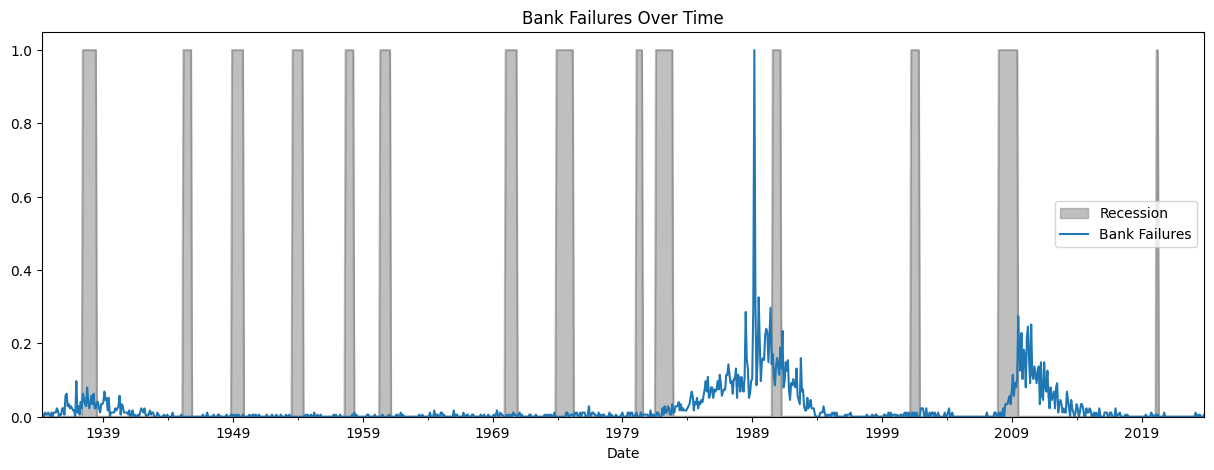

In [6]:
df["Count"] = 1
df = df.resample("M").sum()
df = df[["Count"]]
scaler = MinMaxScaler()
df["Bank Failures"] = scaler.fit_transform(df[["Count"]])

df_data = df.drop("Count", axis=1)

df_recession = df_recession[df_recession.index >= df_data.index[0]]

# plot the data
fig, ax = plt.subplots(figsize=(15, 5))
df_recession.plot.area(ax=ax, alpha=0.5, color="gray")
df_data.plot(ax=ax, title="Bank Failures Over Time")
plt.show()


KeyError: "None of [Index(['Count'], dtype='object', name='Date')] are in the [index]"

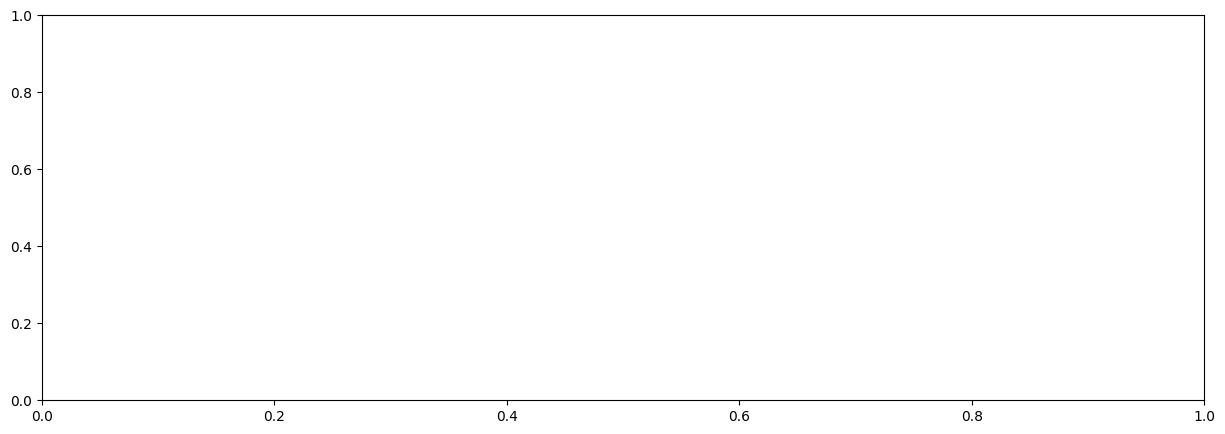

In [7]:
# look at bank failures in the last 4 years
fig, ax = plt.subplots(figsize=(15, 5))
scaler = MinMaxScaler()

df1 = df_recession["Recession"].iloc[-4 * 12 :]
df2 = df["Bank Failures"].iloc[-4 * 12 :]

# count the number of bank failures in this new time frame


df2["Bank Failures"] = scaler.fit_transform(df2[["Count"]])
df2 = df2.drop("Count", axis=1)

df1.plot.area(ax=ax, alpha=0.5, color="gray")
df2.plot(ax=ax)
plt.show()
